In [ ]:
# ==============================================
# IPL AUCTION PRICE PREDICTION
# PART 1
# ==============================================

!pip install -q xgboost

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

# ----------------------------
# Upload Dataset
# ----------------------------

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(df.shape)

df.head()

# ----------------------------
# Remove unwanted columns
# ----------------------------

# Drop columns that should not be used
drop_cols = ["Id", "Name", "Status"]

df.drop(
    columns=[col for col in drop_cols if col in df.columns],
    inplace=True
)

# ----------------------------
# Basic Cleaning
# ----------------------------

for col in df.columns:

    if df[col].dtype=="object":

        df[col]=df[col].fillna(df[col].mode()[0])

    else:

        df[col]=df[col].fillna(df[col].median())

# ----------------------------
# Feature Engineering
# ----------------------------

if {"Runs","LRuns"}.issubset(df.columns):

    df["RunGrowth"]=df["Runs"]-df["LRuns"]

if {"Matches","LMatches"}.issubset(df.columns):

    df["MatchGrowth"]=df["Matches"]-df["LMatches"]

if {"Ave","LAve"}.issubset(df.columns):

    df["AverageGrowth"]=df["Ave"]-df["LAve"]

if {"StrRate","LStrRate"}.issubset(df.columns):

    df["StrikeRateGrowth"]=df["StrRate"]-df["LStrRate"]

if {"Wkts","LWkts"}.issubset(df.columns):

    df["WicketGrowth"]=df["Wkts"]-df["LWkts"]

if {"LEcon","Econ"}.issubset(df.columns):

    df["EconomyChange"]=df["LEcon"]-df["Econ"]

if "Age" in df.columns:

    df["AgeSquared"]=df["Age"]**2

# ----------------------------
# Time Based Split
# ----------------------------

latest_year=df["Year"].max()

train_df=df[df["Year"]<latest_year]

test_df=df[df["Year"]==latest_year]

print("Training:",train_df.shape)
print("Testing :",test_df.shape)

TARGET="Final Price"

X_train=train_df.drop(columns=[TARGET])

y_train=train_df[TARGET]

X_test=test_df.drop(columns=[TARGET])

y_test=test_df[TARGET]

# ----------------------------
# Identify Column Types
# ----------------------------

categorical=X_train.select_dtypes(include="object").columns.tolist()

numeric=X_train.select_dtypes(exclude="object").columns.tolist()

print(categorical)
print(len(numeric))

# ----------------------------
# Preprocessing Pipeline
# ----------------------------

numeric_transformer=Pipeline(

    steps=[

        ("imputer",SimpleImputer(strategy="median"))

    ]

)

categorical_transformer=Pipeline(

    steps=[

        ("imputer",SimpleImputer(strategy="most_frequent")),

        ("encoder",OneHotEncoder(handle_unknown="ignore"))

    ]

)

preprocessor=ColumnTransformer(

    transformers=[

        ("num",numeric_transformer,numeric),

        ("cat",categorical_transformer,categorical)

    ]

)

Saving Data_Mendeley.csv to Data_Mendeley.csv
(1108, 42)
Training: (930, 46)
Testing : (178, 46)
['Role', 'Nationality', 'Team']
42


Training Model...
Training Complete!

MODEL PERFORMANCE
MAE  : 17,583,648.00
RMSE : 25,287,235.13
R²   : 0.4115


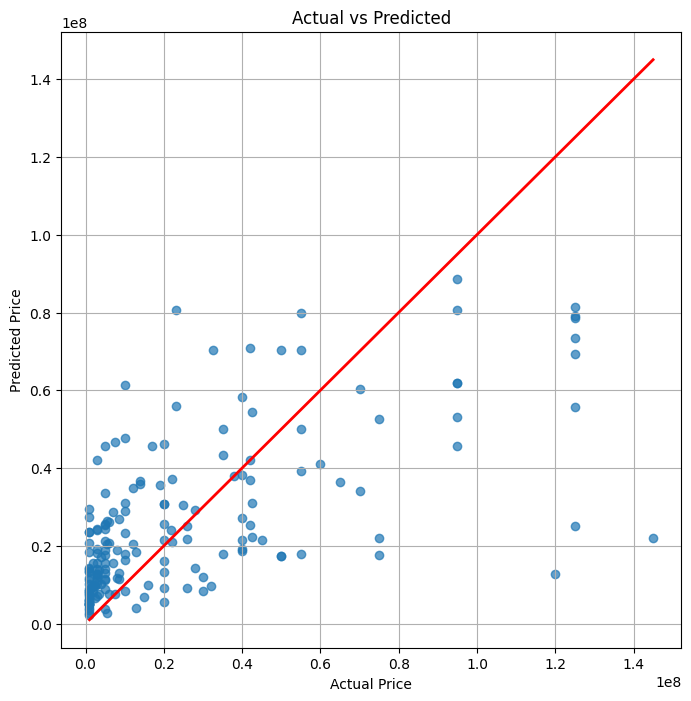

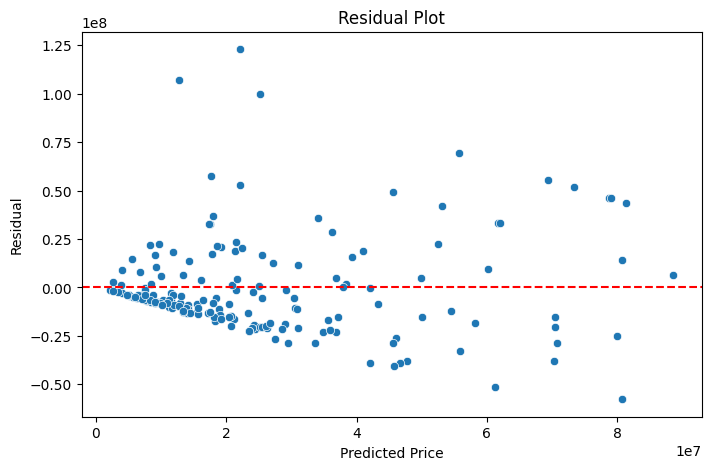

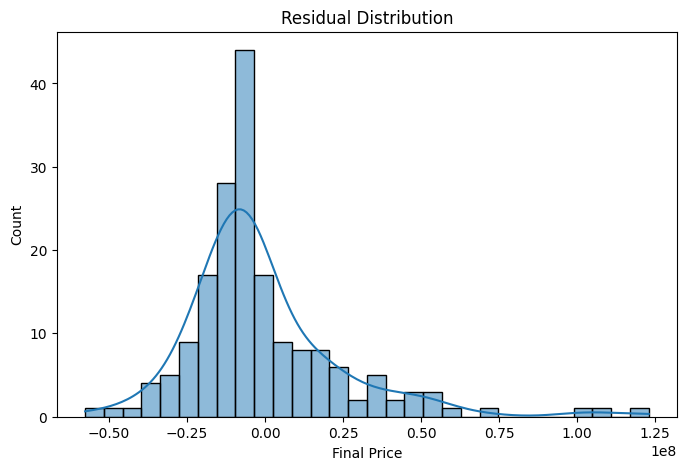

,Year,Role,Nationality,Team,Ent,Age,Matches,LMatches,Runs,LRuns,...,RunGrowth,MatchGrowth,AverageGrowth,StrikeRateGrowth,WicketGrowth,EconomyChange,AgeSquared,Actual Price,Predicted Price,Absolute Error
167,2017,Batsman,English,RPS,0,26,12,0,316,0,...,316,12,31.600000,142.980000,12,-7.18,676,145000000,22067188.0,122932812.0
1000,2017,Batsman,English,RCB,0,24,5,0,8,0,...,8,5,2.660000,72.720000,5,-8.57,576,120000000,12767364.0,107232636.0
246,2017,Batsman,South African,KXIP,1,28,5,14,83,161,...,-78,-9,11.560000,-19.150002,0,0.00,784,125000000,25118016.0,99881984.0
530,2017,Wicketkeeper batsman,Indian,RPS,0,36,16,14,290,284,...,6,2,-14.210000,-19.229996,0,0.00,1296,125000000,55694188.0,69305812.0
283,2017,Wicketkeeper,Indian,GL,0,32,14,16,361,335,...,26,-2,10.340000,13.450000,0,0.00,1024,23000000,80662976.0,57662976.0
512,2017,Bowler,Sri Lankan,MI,0,34,12,0,7,0,...,7,12,0.000000,233.330000,11,-8.52,1156,75000000,17695754.0,57304246.0
970,2017,Batsman,Indian,GL,0,31,14,15,442,399,...,43,-1,11.680000,16.090003,1,-0.30,961,125000000,69387048.0,55612952.0
432,2017,All-rounder,Australian,GL,0,27,8,7,54,77,...,-23,1,-12.160000,-35.770000,4,0.03,729,75000000,22074724.0,52925276.0
1052,2017,Batsman,Indian,RCB,0,29,10,16,308,973,...,-665,-6,-50.280002,-29.809999,0,13.00,841,125000000,73324800.0,51675200.0
633,2017,All-rounder,Australian,SRH,0,30,12,17,277,182,...,95,-5,31.000000,21.270000,-11,-2.35,900,10000000,61253960.0,51253960.0


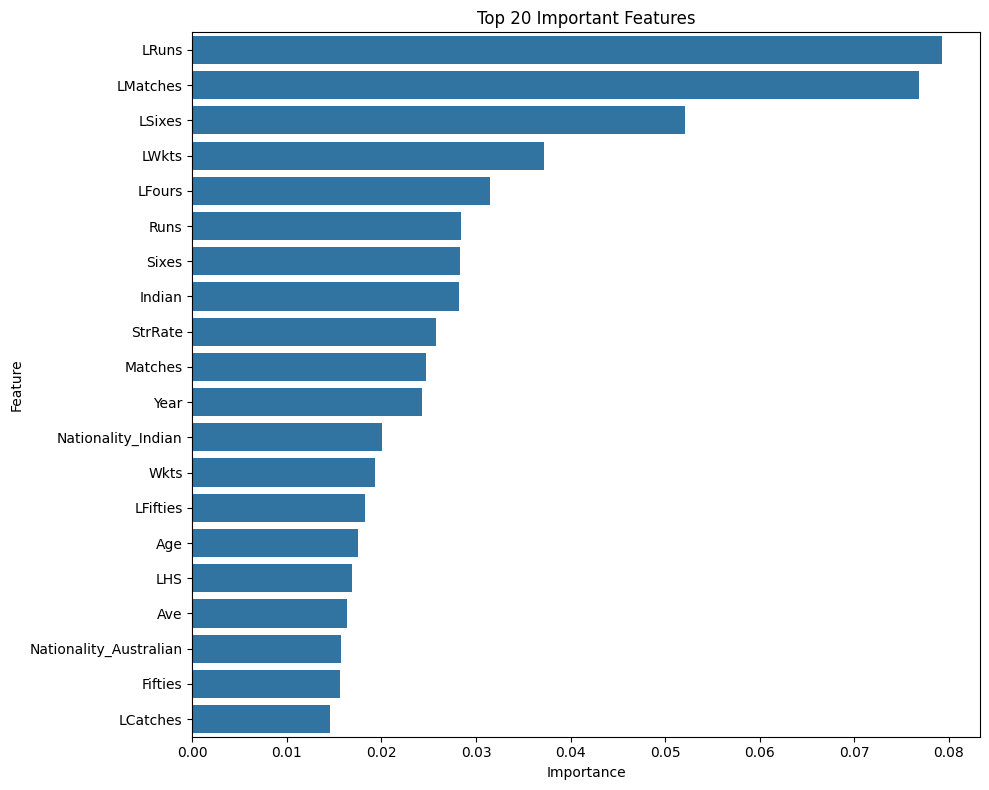


Top 20 Features


,Feature,Importance
6,LRuns,0.079341
4,LMatches,0.076809
20,LSixes,0.052062
26,LWkts,0.037176
18,LFours,0.031470
5,Runs,0.028452
19,Sixes,0.028288
33,Indian,0.028201
11,StrRate,0.025806
3,Matches,0.024678


Model Saved Successfully!

Predicted Auction Price
₹ 13,306,133.00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

# ==============================================
# PART 2
# Build Model + Train + Evaluate
# ==============================================

from sklearn.pipeline import Pipeline

# ----------------------------
# Create Pipeline
# ----------------------------

model = XGBRegressor(
    objective="reg:squarederror",

    n_estimators=250,

    learning_rate=0.05,

    max_depth=3,

    min_child_weight=8,

    gamma=0.5,

    subsample=0.7,

    colsample_bytree=0.7,

    reg_alpha=1,

    reg_lambda=5,

    random_state=42,

    n_jobs=-1
)

pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", model)

    ]

)

# ----------------------------
# Train Model
# ----------------------------

print("Training Model...")

pipeline.fit(

    X_train,

    y_train

)

print("Training Complete!")

# ----------------------------
# Feature Importance (Moved up)
# ----------------------------

ohe = pipeline.named_steps["preprocessor"] \
              .named_transformers_["cat"] \
              .named_steps["encoder"]

cat_features = ohe.get_feature_names_out(categorical)

feature_names = numeric + list(cat_features)

importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importances

})

importance_df = importance_df.sort_values(

    "Importance",

    ascending=False

)

importance_df.sort_values("Importance", ascending=False).head(30)

# ----------------------------
# Predictions
# ----------------------------

train_pred = pipeline.predict(X_train)

test_pred = pipeline.predict(X_test)

# ----------------------------
# Metrics
# ----------------------------

mae = mean_absolute_error(

    y_test,

    test_pred

)

rmse = np.sqrt(

    mean_squared_error(

        y_test,

        test_pred

    )

)

r2 = r2_score(

    y_test,

    test_pred

)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"MAE  : {mae:,.2f}")

print(f"RMSE : {rmse:,.2f}")

print(f"R²   : {r2:.4f}")

# ----------------------------
# Actual vs Predicted
# ----------------------------

plt.figure(figsize=(8,8))

plt.scatter(

    y_test,

    test_pred,

    alpha=0.7

)

plt.plot(
`
    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red",

    linewidth=2

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

# ----------------------------
# Residual Plot
# ----------------------------

residuals = y_test - test_pred

plt.figure(figsize=(8,5))

sns.scatterplot(

    x=test_pred,

    y=residuals

)

plt.axhline(

    0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# ----------------------------
# Error Distribution
# ----------------------------

plt.figure(figsize=(8,5))

sns.histplot(

    residuals,

    bins=30,

    kde=True

)

plt.title("Residual Distribution")

plt.show()

print("\n--- Attempting to display Prediction Table ---")
# ----------------------------
# Prediction Table
# ----------------------------

results = X_test.copy()

results["Actual Price"] = y_test.values

results["Predicted Price"] = test_pred

results["Absolute Error"] = (

    results["Actual Price"] -

    results["Predicted Price"]

).abs()

display(

    results.sort_values(

        "Absolute Error",

        ascending=False

    ).head(20)

)
print("--- Prediction Table displayed successfully ---")

print("\n--- Attempting to display Feature Importance Plot and Table ---")
# ----------------------------
# Feature Importance (Plotting)
# ----------------------------

plt.figure(figsize=(10,8))

sns.barplot(

    data=importance_df.head(20),

    y="Feature",

    x="Importance"

)

plt.title("Top 20 Important Features")

plt.tight_layout()

plt.show()

print("\nTop 20 Features")

display(

    importance_df.head(20)

)
print("--- Feature Importance Plot and Table displayed successfully ---")

print("\n--- Attempting to Save Model ---")
# ----------------------------
# Save Model
# ----------------------------

import joblib

joblib.dump(

    pipeline,

    "ipl_xgboost_pipeline.pkl"

)

print("Model Saved Successfully!")
print("--- Model Saved Successfully ---")

print("\n--- Attempting to Predict New Player ---")
# ----------------------------
# Predict New Player
# ----------------------------

new_player = X_train.iloc[[0]].copy()

if "Age" in new_player.columns:
    new_player["Age"] = 25

if "Runs" in new_player.columns:
    new_player["Runs"] = 650

if "Ave" in new_player.columns:
    new_player["Ave"] = 48

if "StrRate" in new_player.columns:
    new_player["StrRate"] = 145

if "Wkts" in new_player.columns:
    new_player["Wkts"] = 10

prediction = pipeline.predict(new_player)

print("\nPredicted Auction Price")

print(f"₹ {prediction[0]:,.2f}")
print("--- New Player Prediction Complete ---")

In [ ]:
train_pred = pipeline.predict(X_train)

print("Train R2 :", r2_score(y_train, train_pred))
print("Test R2 :", r2_score(y_test, test_pred))